In [1]:
!pip install xarray
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 37.2 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/cartopy/io/__init__.py:242: DownloadWarning: Downloading: https://naturalearth.s3.amazonaws.com/110m_physical/ne_110m_coastline.zip
  warnings.warn(f'Downloading: {url}', DownloadWarning)


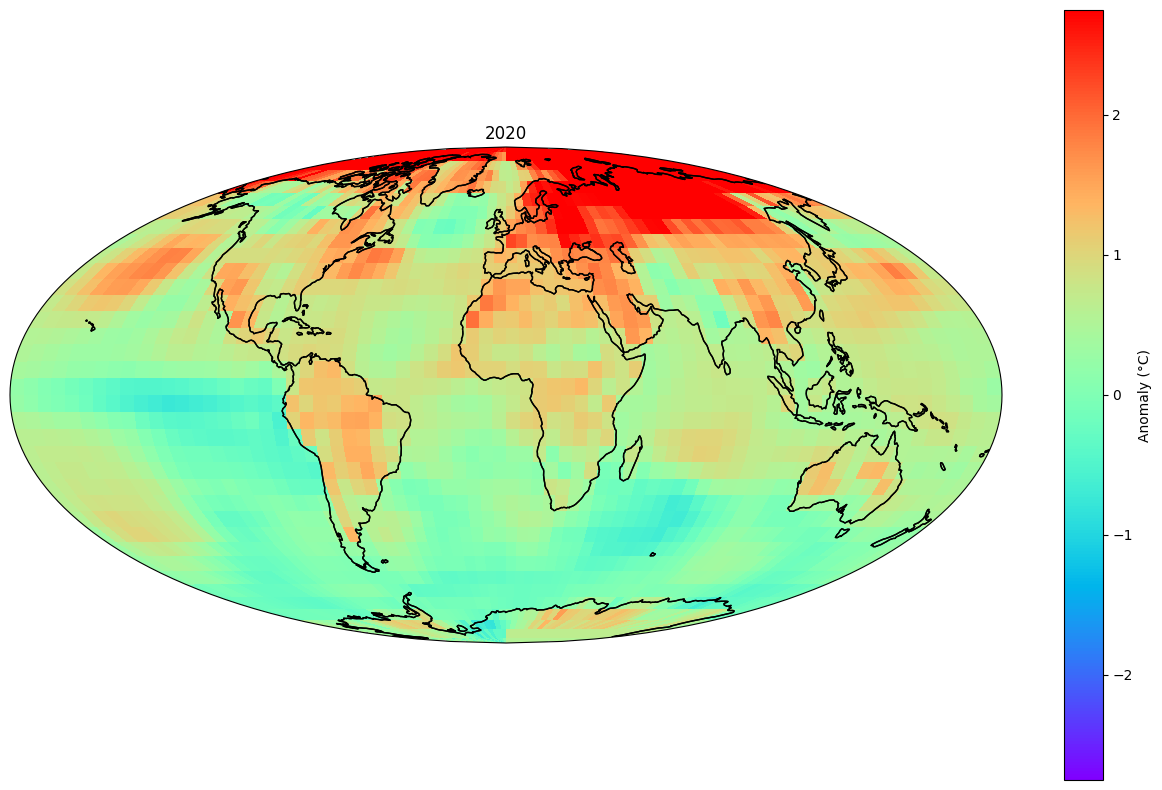

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import cartopy.crs as ccrs

#url = 'https://www.ncei.noaa.gov/thredds/dodsC/noaa-global-temp-v5/NOAAGlobalTemp_v5.0.0_gridded_s188001_e202212_c20230108T133308.nc'
xrds = xr.open_dataset("NOAAGlobalTemp_v6.0.0_gridded_s185001_e202501_c20250206T150119.nc")

# Select one year of data and then find the mean annual temperature anomalies
year = 2020
data_for_desired_year = xrds.sel(time=slice(f'{year}-01-01', f'{year}-12-31'))
mean_annual_anom = data_for_desired_year['anom'].mean(dim='time')

fig = plt.figure(figsize=(16, 10))

projection = ccrs.Mollweide(central_longitude=0, false_easting=0, false_northing=1) #original
#projection = ccrs.EqualEarth()
transform = ccrs.PlateCarree()
ax = plt.axes(projection=projection)

vmin = -2.75
vmax = 2.75
pcm = mean_annual_anom.plot(ax=ax, transform=transform, vmin=vmin, vmax=vmax, cmap='rainbow', add_colorbar=False)
ax.coastlines()

# Get the extent of the data
xmin, xmax, ymin, ymax = ax.get_extent(transform)

# Create a patch to fill the areas outside the data extent with grey
ax.add_patch(plt.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                        facecolor='grey', transform=transform, zorder=-1))

ax.coastlines()
ax.set_global()

cbar = plt.colorbar(pcm, ax=ax, orientation='vertical')
cbar.set_label('Anomaly (°C)')
ax.set_title(f'{year}')

plt.savefig(f'global_surface_temp_anomalies_{year}_r.png', transparent=True)
plt.gcf().set_dpi(100)
plt.show()

In [4]:
xrds

<xarray.Dataset> Size: 22MB
Dimensions:  (time: 2101, z: 1, lat: 36, lon: 72)
Coordinates:
  * time     (time) datetime64[ns] 17kB 1850-01-01 1850-02-01 ... 2025-01-01
  * z        (z) float32 4B 0.0
  * lat      (lat) float32 144B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float32 288B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
Data variables:
    anom     (time, z, lat, lon) float32 22MB ...
Attributes: (12/66)
    Conventions:                     CF-1.6, ACDD-1.3
    title:                           NOAA Merged Land Ocean Global Surface Te...
    summary:                         NOAAGlobalTemp is a merged land-ocean su...
    institution:                     DOC/NOAA/NESDIS/National Centers for Env...
    id:                               gov.noaa.ncdc:C00934 
    naming_authority:                 gov.noaa.ncei 
    ...                              ...
    time_coverage_duration:          P175Y1M
    references:                      Vose, R. S., et al., 2012: NOAAs merged ...
    climatology:                     Climatology is based on 1971-2000 monthl...
    acknowledgment:                  The NOAA Global Surface Temperature Data...
    date_modified:                   2025-02-06T20:01:21Z
    date_issued:                     2025-02-06T20:01:21Z

In [5]:
mean_annual_anom

<xarray.DataArray 'anom' (z: 1, lat: 36, lon: 72)> Size: 10kB
array([[[ 0.18167634, -0.02379224,  0.07949758, ..., -0.3425726 ,
         -0.24674277,  0.00823367],
        [-0.34744358, -0.00954429, -0.01618092, ..., -0.35605708,
         -0.36290267, -0.3820697 ],
        [-0.10457841,  0.18858723,  0.39275706, ..., -0.80388474,
         -0.47960523, -0.3125305 ],
        ...,
        [ 0.5985283 ,  0.8842116 ,  1.662584  , ...,  1.0327864 ,
          0.8853528 ,  0.6191752 ],
        [ 1.3874344 ,  1.569756  ,  1.8004556 , ...,  1.9952852 ,
          1.8046979 ,  1.6239676 ],
        [ 2.4528625 ,  2.6321661 ,  2.415168  , ...,  2.4736059 ,
          2.668848  ,  2.472592  ]]], dtype=float32)
Coordinates:
  * z        (z) float32 4B 0.0
  * lat      (lat) float32 144B -87.5 -82.5 -77.5 -72.5 ... 72.5 77.5 82.5 87.5
  * lon      (lon) float32 288B 2.5 7.5 12.5 17.5 ... 342.5 347.5 352.5 357.5
Attributes:
    long_name:              Global Temperature Anomalies
    standard_name:          surface_temperature_anomaly
    coverage_content_type:  physicalMeasurement
    units:                  degrees C
    valid_min:              -40.0
    valid_max:              40.0

# **Year 2015**

Text(0.5, 0, 'lon')

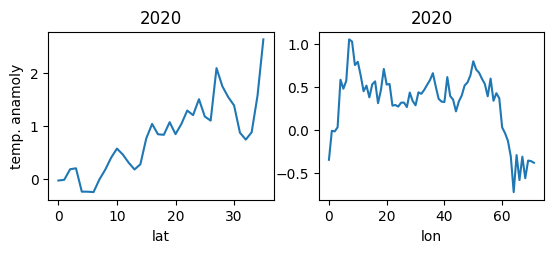

In [6]:
year=year;
mean_annual_anom_reshape_2015=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2015[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2015[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

In [8]:
interpolation='bicubic'

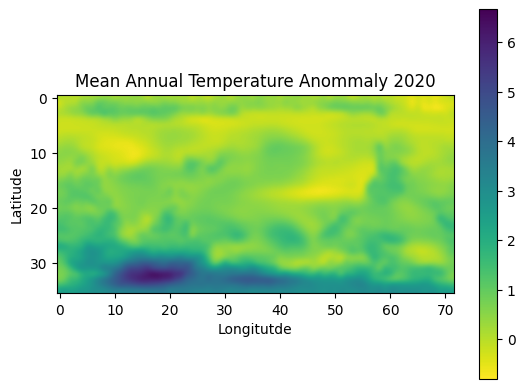

In [10]:
plt.imshow((mean_annual_anom_reshape_2015).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()
plt.show()

# **Year 2016**

Text(0.5, 0, 'lon')

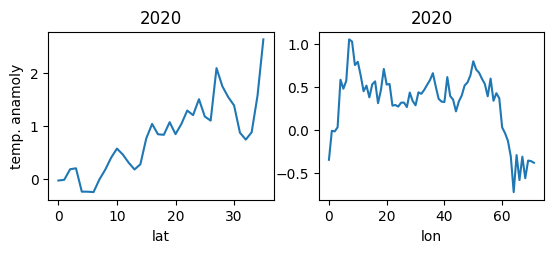

In [11]:
year=year;
mean_annual_anom_reshape_2016=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2016[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2016[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

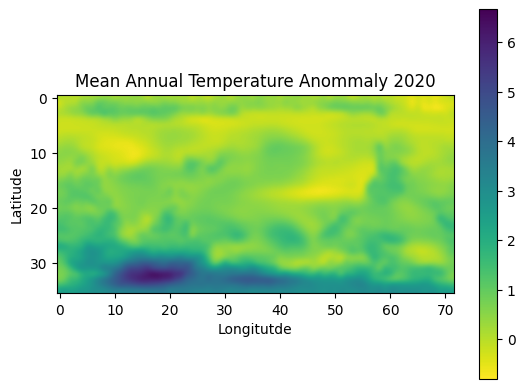

In [12]:
plt.imshow((mean_annual_anom_reshape_2016).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2017**

Text(0.5, 0, 'lon')

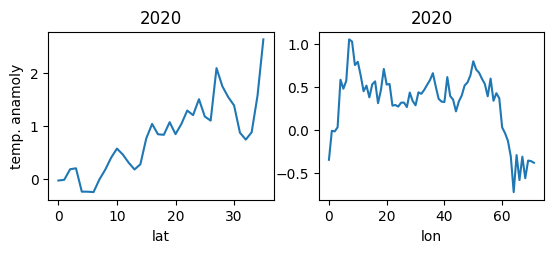

In [13]:
year=year;
mean_annual_anom_reshape_2017=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2017[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2017[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

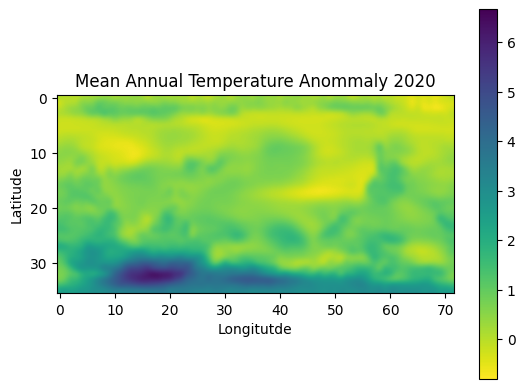

In [14]:
plt.imshow((mean_annual_anom_reshape_2017).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2018**

Text(0.5, 0, 'lon')

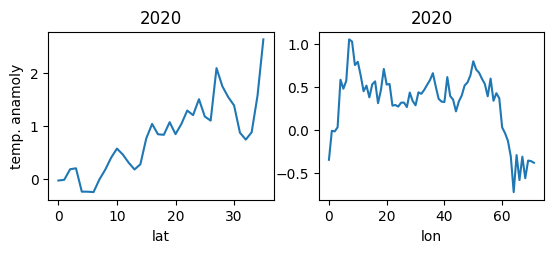

In [15]:
year=year;
mean_annual_anom_reshape_2018=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2018[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2018[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

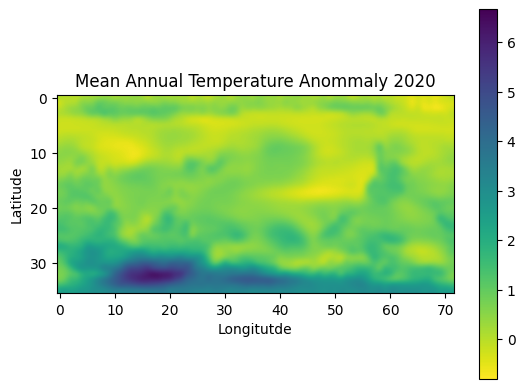

In [17]:
plt.imshow((mean_annual_anom_reshape_2018).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2019**

Text(0.5, 0, 'lon')

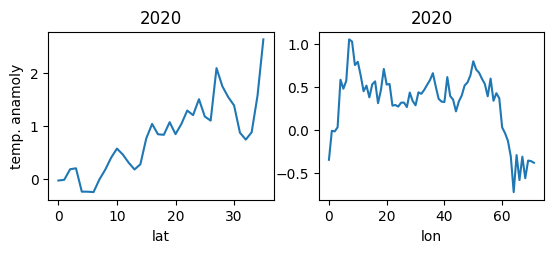

In [18]:
year=year;
mean_annual_anom_reshape_2019=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2019[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2019[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

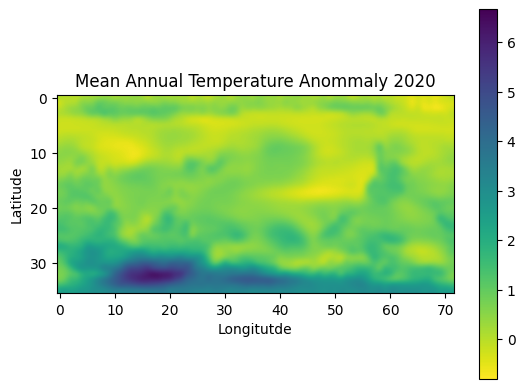

In [19]:
plt.imshow((mean_annual_anom_reshape_2019).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2020**

Text(0.5, 0, 'lon')

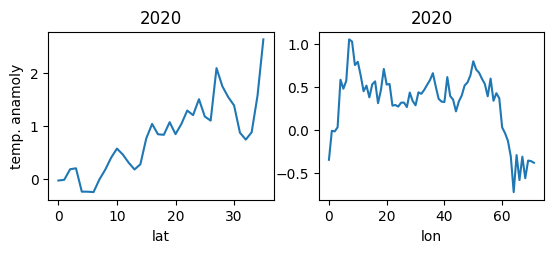

In [20]:
year=year;
mean_annual_anom_reshape_2020=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2020[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2020[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

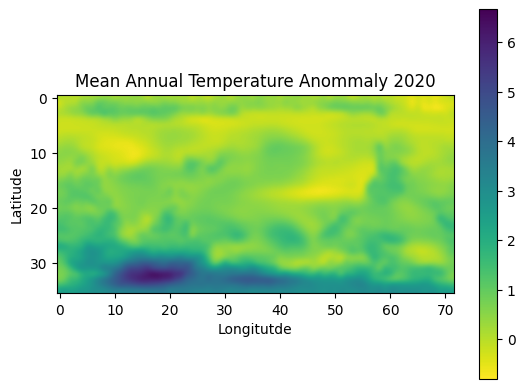

In [21]:
plt.imshow((mean_annual_anom_reshape_2020).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2021**

Text(0.5, 0, 'lon')

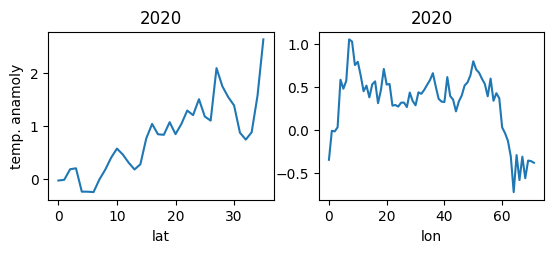

In [22]:
year=year;
mean_annual_anom_reshape_2021=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2021[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2021[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

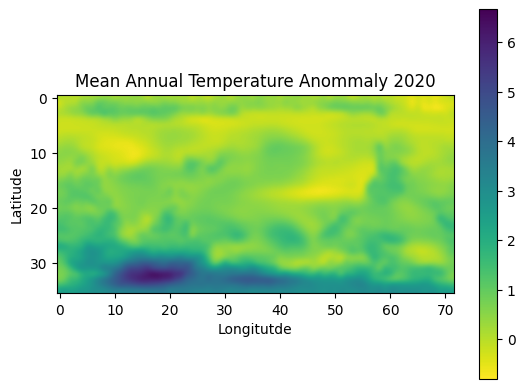

In [23]:
plt.imshow((mean_annual_anom_reshape_2021).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2022**

Text(0.5, 0, 'lon')

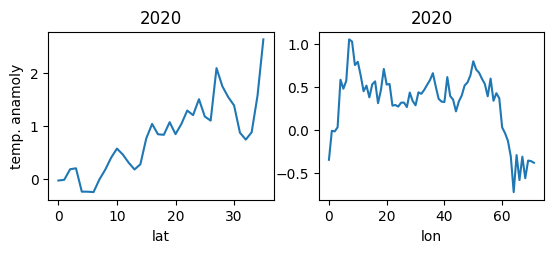

In [24]:
year=year;
mean_annual_anom_reshape_2022=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2022[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2022[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

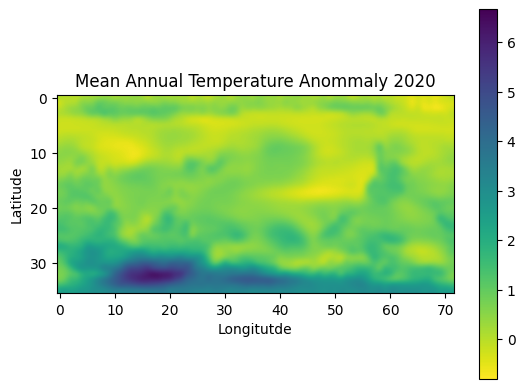

In [25]:
plt.imshow((mean_annual_anom_reshape_2022).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2023**

Text(0.5, 0, 'lon')

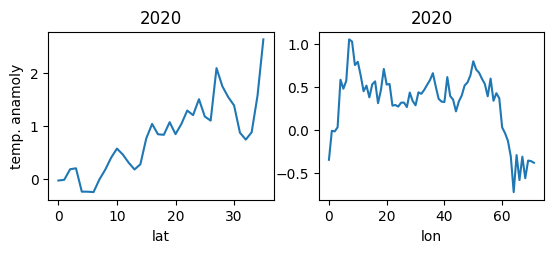

In [26]:
year=year;
mean_annual_anom_reshape_2023=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2023[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2023[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

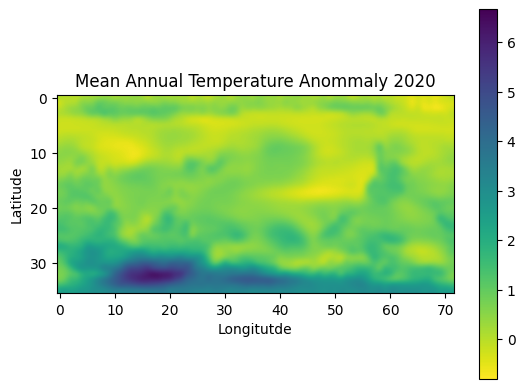

In [27]:
plt.imshow((mean_annual_anom_reshape_2023).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Year 2024**

Text(0.5, 0, 'lon')

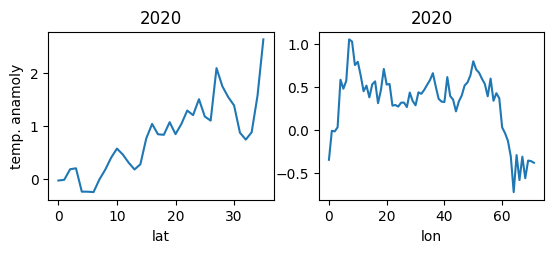

In [28]:
year=year;
mean_annual_anom_reshape_2024=np.array(mean_annual_anom).reshape(36,72)
ax1_lat=plt.subplot(221)
ax2_lon=plt.subplot(222)
ax1_lat.plot(mean_annual_anom_reshape_2024[:,1])
ax1_lat.set_title(f"{year}")
ax1_lat.set_xlabel("lat")
ax1_lat.set_ylabel("temp. anamoly")
ax2_lon.plot(mean_annual_anom_reshape_2024[1,:])
ax2_lon.set_title(f"{year}")
ax2_lon.set_xlabel("lon")
#ax2_lon.set_ylabel("temp. anamoly")

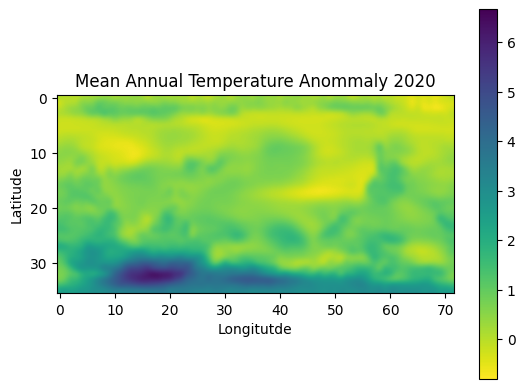

In [30]:
plt.imshow((mean_annual_anom_reshape_2024).reshape(36,72),cmap="viridis_r",interpolation=interpolation)
plt.title(f"Mean Annual Temperature Anommaly {year}")
plt.xlabel("Longitutde")
plt.ylabel("Latitude")
plt.colorbar()

# **Buliding data matrix for Kernel eDMD**

In [31]:
W=[mean_annual_anom_reshape_2015.reshape(-1),
    mean_annual_anom_reshape_2016.reshape(-1),
    mean_annual_anom_reshape_2017.reshape(-1),
    mean_annual_anom_reshape_2018.reshape(-1),
    mean_annual_anom_reshape_2019.reshape(-1),
    mean_annual_anom_reshape_2020.reshape(-1),
    mean_annual_anom_reshape_2021.reshape(-1),
    mean_annual_anom_reshape_2022.reshape(-1),
    mean_annual_anom_reshape_2023.reshape(-1),
    mean_annual_anom_reshape_2024.reshape(-1)];

In [32]:
np.array(W).transpose()

array([[ 0.18167634,  0.18167634,  0.18167634, ...,  0.18167634,
         0.18167634,  0.18167634],
       [-0.02379224, -0.02379224, -0.02379224, ..., -0.02379224,
        -0.02379224, -0.02379224],
       [ 0.07949758,  0.07949758,  0.07949758, ...,  0.07949758,
         0.07949758,  0.07949758],
       ...,
       [ 2.4736059 ,  2.4736059 ,  2.4736059 , ...,  2.4736059 ,
         2.4736059 ,  2.4736059 ],
       [ 2.668848  ,  2.668848  ,  2.668848  , ...,  2.668848  ,
         2.668848  ,  2.668848  ],
       [ 2.472592  ,  2.472592  ,  2.472592  , ...,  2.472592  ,
         2.472592  ,  2.472592  ]], dtype=float32)

In [33]:
np.array(W).transpose().shape

(2592, 10)

In [34]:
36*72*10

25920

Text(0.5, 1.0, 'Anamoly distribution over #10 years')

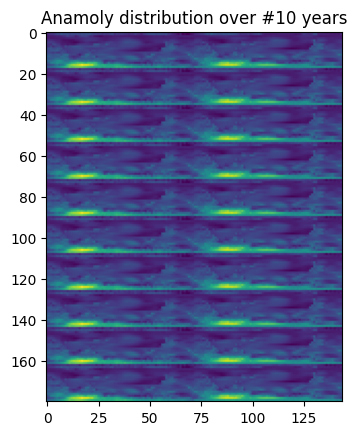

In [35]:
plt.imshow(np.array(W).reshape(36*5,72*2))
plt.title("Anamoly distribution over #10 years")

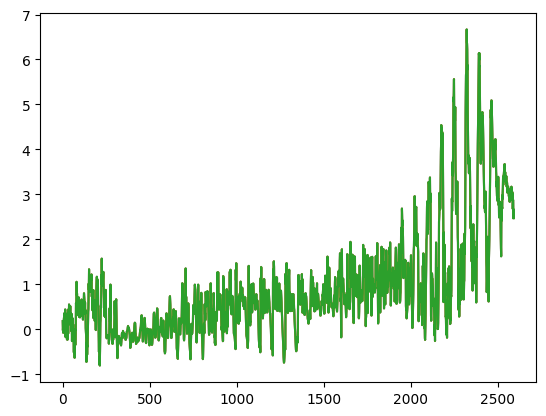

In [36]:
plt.plot(np.array(W)[7])
plt.plot(np.array(W)[8])
plt.plot(np.array(W)[9])

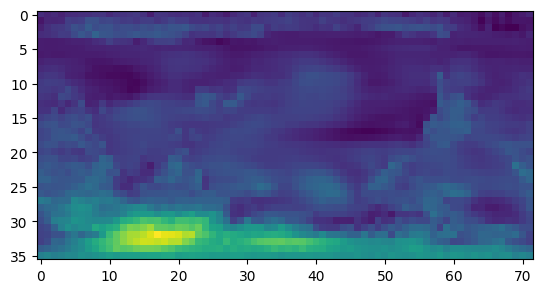

In [37]:
plt.imshow(W[9].reshape(36,72))

In [ ]:
np.savez_compressed('weather_anamoly',W)